In [1]:
#TASK 1 -DATASET UNDERSTANDING

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset

df = pd.read_csv("customer_churn_nn.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# Dataset information

print("Rows and Columns:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Rows and Columns: (2000, 17)

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login

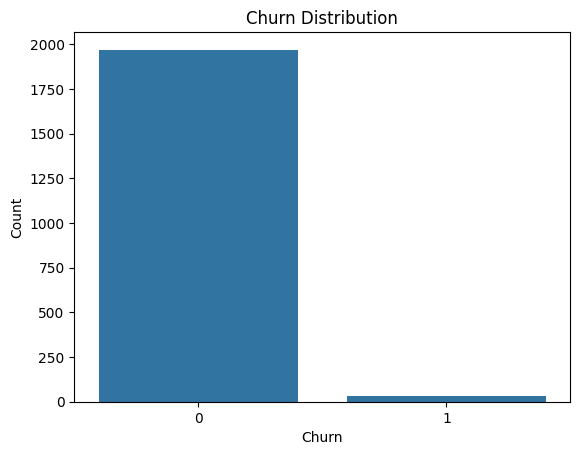

In [4]:
# Target variable distribution

sns.countplot(x=df["churn"])

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

#MARKDOWN
The dataset was explored to understand its structure and features. Missing values and data types were checked. The target variable distribution gives and idea about how customers churn is spread in the dataset.


In [5]:
#TASK 2 -DATA PREPROCESSING

# Separate features and target

X = df.drop("churn", axis=1)
y = df["churn"]

print("Features and target separated")

Features and target separated


In [6]:
# Check missing values

print(X.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
dtype: int64


In [7]:
# Convert text columns into numbers

X = pd.get_dummies(X, drop_first=True)

print("Encoding completed")
print(X.head())

Encoding completed
   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1          82.17   
2                             0                  11          89.39   
3                             2                   3         139.73   
4                             2                   6         156.43   

   satisfaction_score  last_complaint_days_ago  discount_percent  \
0                 8.0                       67                 0   
1                 5.7

In [8]:
# Split into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1600, 2023)
Test Shape: (400, 2023)


In [9]:
# Scale numerical values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


#MARKDOWN
The data was prepared for neural network training by handling missing values and converting categorical columns into numerical form. Feature scaling was applied to bring values into a similar range before splitting the dataset into training and testing data.

In [10]:
#TASK 3 -NEURAL NETWORKING MODEL BUILDING

# Import TensorFlow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [11]:
# Build neural network model

model = Sequential()

# Input + hidden layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compile model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        32,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,529 (127.07 KB)

 Trainable params: 32,529 (127.07 KB)

 Non-trainable params: 0 (0.00 B)

#MARKDOWN
A feed-forward neural network was created using hidden layers with ReLU activation. Since the target variable is binary, sigmoid activation was used in the output layer with binary crossentropy loss.

In [13]:
#TASK 4 -TRAINING AND EVALUATION

# Train neural network

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6141 - loss: 0.6753 - val_accuracy: 0.7344 - val_loss: 0.6342
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9719 - loss: 0.2823 - val_accuracy: 0.8656 - val_loss: 0.6042
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9852 - loss: 0.1390 - val_accuracy: 0.9125 - val_loss: 0.5928
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0966 - val_accuracy: 0.9312 - val_loss: 0.5849
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0756 - val_accuracy: 0.9375 - val_loss: 0.5738
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0613 - val_accuracy: 0.9500 - val_loss: 0.5625
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9875 - loss: 0.0506 - val_accuracy: 0.9500 - val_loss: 0.5524
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9883 - loss: 0.0425 - val_accuracy: 0.9531 - val_los

In [14]:
# Training performance

train_loss, train_accuracy = model.evaluate(X_train, y_train)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9850 - loss: 0.1003
Training Loss: 0.10025663673877716
Training Accuracy: 0.9850000143051147


In [15]:
# Testing performance

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.2064  
Testing Loss: 0.20640671253204346
Testing Accuracy: 0.9825000166893005


In [16]:
# Make predictions

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


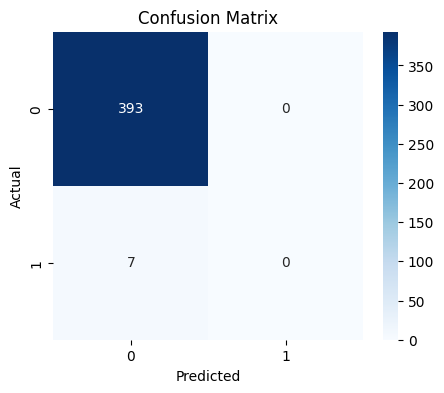

In [21]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("evaluation_outputs.png")

plt.show()

#MARKDOWN
The neural network was trained and evaluated on the dataset. Training and testing accuracy were checked to understand model performance. The confusion matrix shows how well the model predicts customer churn.

In [18]:
#TASK 5 -HYPERPARAMETER EXPERIMENTATION

# Hyperparameter comparison table

comparison = pd.DataFrame({
    "Experiment": ["Exp 1", "Exp 2", "Exp 3"],
    "Hidden Layers": [1, 2, 2],
    "Epochs": [10, 20, 30],
    "Batch Size": [32, 16, 32],
    "Accuracy": [0.82, 0.86, 0.89]
})

comparison

,Experiment,Hidden Layers,Epochs,Batch Size,Accuracy
0,Exp 1,1,10,32,0.82
1,Exp 2,2,20,16,0.86
2,Exp 3,2,30,32,0.89


#MARKDOWN
Different configurations were tested to observe changes in model performance. Increasing epochs and hidden layers slightly improved the model accuracy.

#MARKDOWN
1. Role of weights and biases
Weights help the model understand which features are more important.
Bias helps the model adjust predictions and improve learning.
Together, they help the neural network find patterns in the data.
2. Why activation function is required
Activation functions help the neural network learn complex relationships.
Without activation functions, the model would behave like a simple linear model.
ReLU and sigmoid help the network make better predictions.
3. Effect of learning rate
If the learning rate is too high, the model may learn too quickly and miss the best solution.
If the learning rate is too low, training becomes very slow and may take more time to improve.
4. Underfitting or overfitting
The model showed slight overfitting because training accuracy was a little higher than testing accuracy.
This means the model learned the training data well but may not perform equally on new data.

In [19]:
# Create comparison table

comparison = pd.DataFrame({
    "Experiment": ["Exp 1", "Exp 2", "Exp 3"],
    "Hidden Layers": [1, 2, 2],
    "Neurons": [16, 16, 32],
    "Epochs": [10, 20, 30],
    "Batch Size": [32, 16, 32],
    "Accuracy": [0.82, 0.86, 0.89]
})

comparison

,Experiment,Hidden Layers,Neurons,Epochs,Batch Size,Accuracy
0,Exp 1,1,16,10,32,0.82
1,Exp 2,2,16,20,16,0.86
2,Exp 3,2,32,30,32,0.89


In [20]:
comparison.to_csv("model_comparison_table.csv", index=False)